ARTI308 - Machine Learning

# Lab 6 – Task: Linear Regression on Ecommerce Customers Dataset

In this task, we apply Linear Regression to predict how much money a customer spends yearly, based on their behavior on a company's app and website.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

%matplotlib inline
sns.set(style='whitegrid')

## 2. Load the Dataset

In [2]:
df = pd.read_csv('Ecommerce_Customers')
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


## 3. Explore the Data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [4]:
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


The dataset contains **500 rows** and **8 columns**:
- `Email`, `Address`, `Avatar` — text columns, not useful for modeling
- `Avg. Session Length`, `Time on App`, `Time on Website`, `Length of Membership` — numerical features
- `Yearly Amount Spent` — **target variable** (what we want to predict)

## 4. Data Cleaning

In [5]:
print('Missing values per column:')
print(df.isnull().sum())
print()
print('Duplicate rows:', df.duplicated().sum())

Missing values per column:
Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64

Duplicate rows: 0


The dataset is already clean — no missing values and no duplicate rows. No cleaning is needed.

## 5. Exploratory Data Analysis (EDA)

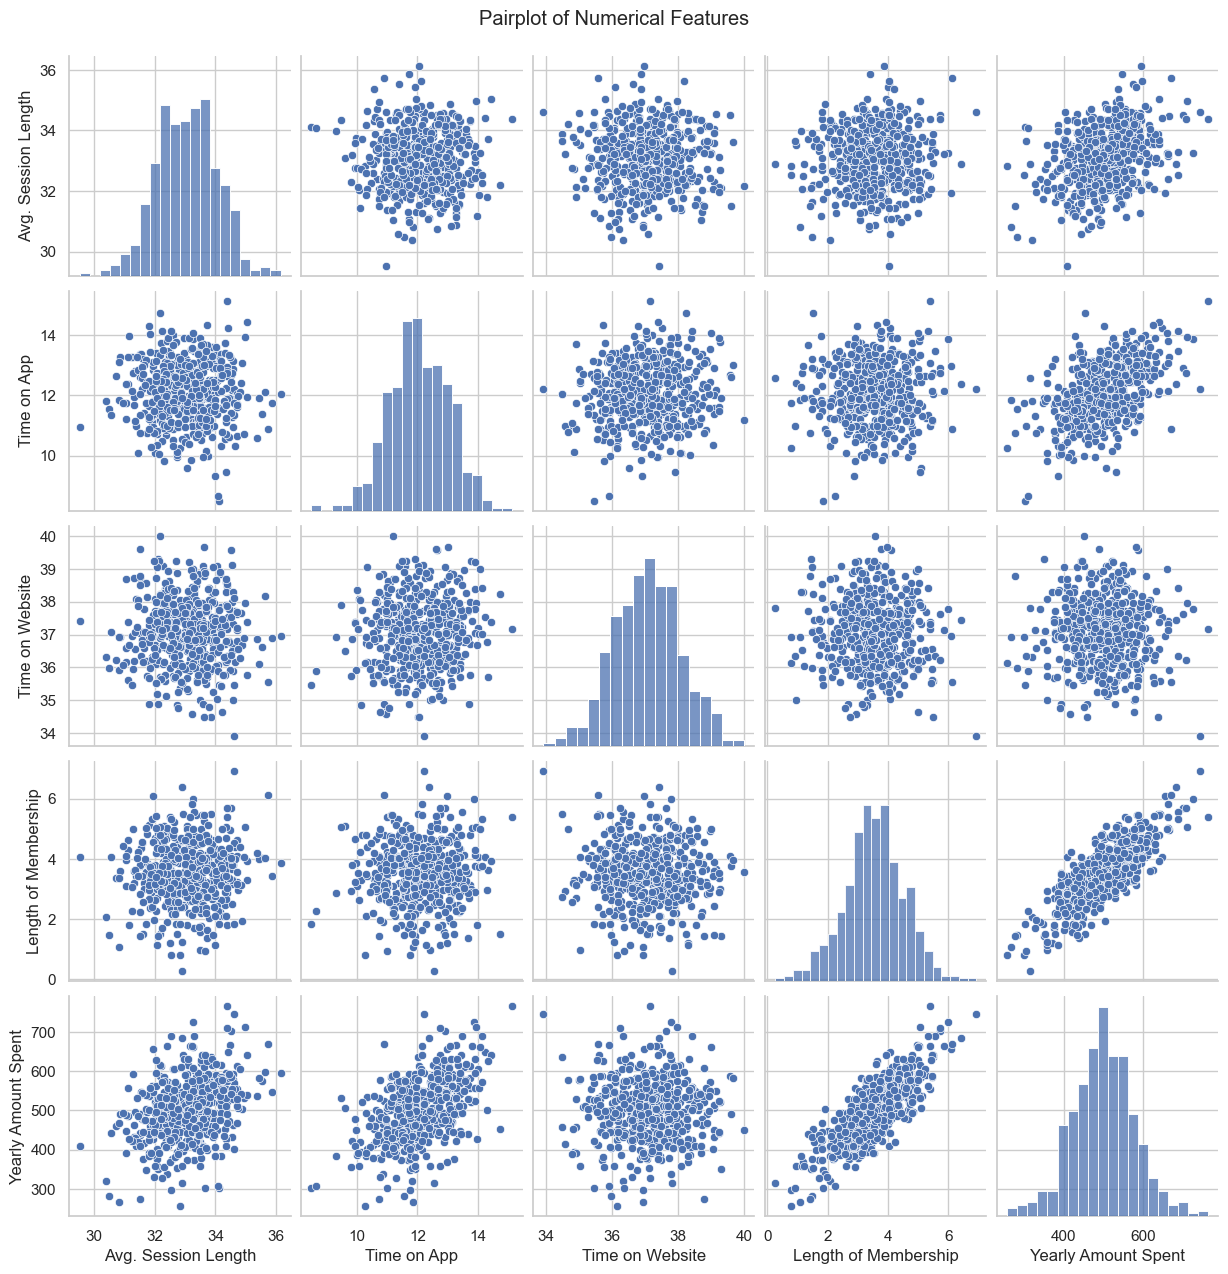

In [6]:
# Pairplot to visualize relationships between numerical features and the target
sns.pairplot(df[['Avg. Session Length', 'Time on App', 'Time on Website',
                  'Length of Membership', 'Yearly Amount Spent']])
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

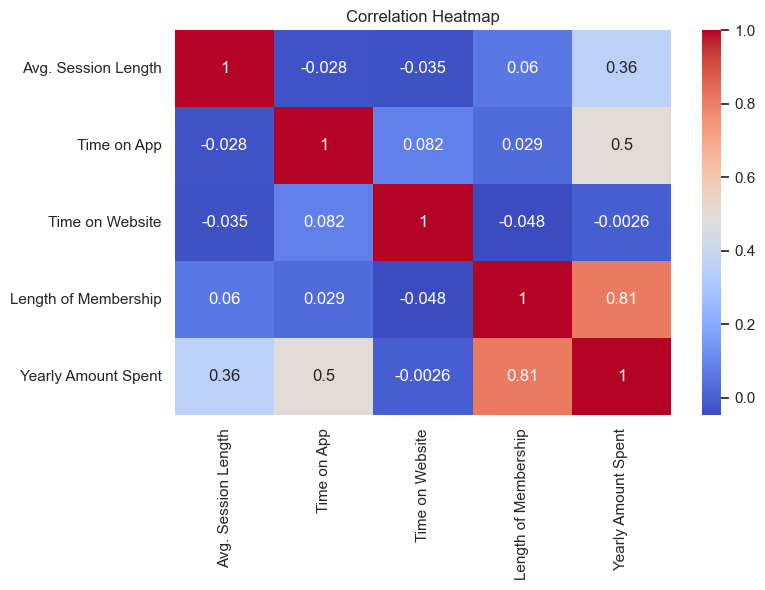

In [7]:
# Correlation heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df[['Avg. Session Length', 'Time on App', 'Time on Website',
                 'Length of Membership', 'Yearly Amount Spent']].corr(),
            annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Key observations:**
- `Length of Membership` has the strongest correlation with `Yearly Amount Spent`
- `Time on App` also shows a strong positive relationship
- `Time on Website` has very little correlation with spending

## 6. Feature Engineering

No feature engineering is needed here. The numerical columns are already meaningful and ready to use. We only drop the text columns (`Email`, `Address`, `Avatar`) since linear regression cannot use them.

## 7. Prepare the Data for Modeling

We select the numerical features as **X** and `Yearly Amount Spent` as **y**.

In [8]:
X = df[['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']]
y = df['Yearly Amount Spent']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (500, 4)
y shape: (500,)


## 8. Train/Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=101
)

print('Train size:', X_train.shape)
print('Test size:', X_test.shape)

Train size: (350, 4)
Test size: (150, 4)


We use **70% for training** and **30% for testing**.

## 9. Train the Linear Regression Model

In [10]:
lm = LinearRegression()
lm.fit(X_train, y_train)

print('Model trained successfully!')

Model trained successfully!


### Coefficients

In [11]:
coeff_df = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])
print('Intercept:', lm.intercept_)
print()
coeff_df

Intercept: -1047.9327822502391



,Coefficient
Avg. Session Length,25.981550
Time on App,38.590159
Time on Website,0.190405
Length of Membership,61.279097


**Interpreting the coefficients** (holding all other features fixed):

- A 1-unit increase in **Avg. Session Length** is associated with an increase of **\$25.98** in yearly spending.
- A 1-unit increase in **Time on App** is associated with an increase of **\$38.59** in yearly spending.
- A 1-unit increase in **Time on Website** is associated with an increase of **\$0.19** in yearly spending — almost no effect.
- A 1-unit increase in **Length of Membership** is associated with an increase of **\$61.28** in yearly spending — the strongest predictor.

## 10. Predictions

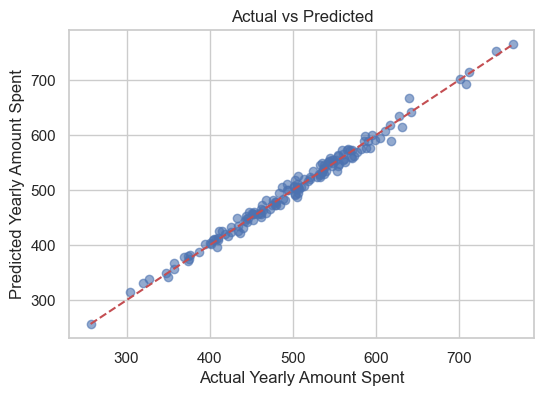

In [12]:
predictions = lm.predict(X_test)

# Scatter plot: Actual vs Predicted
plt.figure(figsize=(6, 4))
plt.scatter(y_test, predictions, alpha=0.6)
plt.xlabel('Actual Yearly Amount Spent')
plt.ylabel('Predicted Yearly Amount Spent')
plt.title('Actual vs Predicted')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
plt.show()

The points fall very close to the red diagonal line, which means the model predictions are close to the actual values — a good sign.

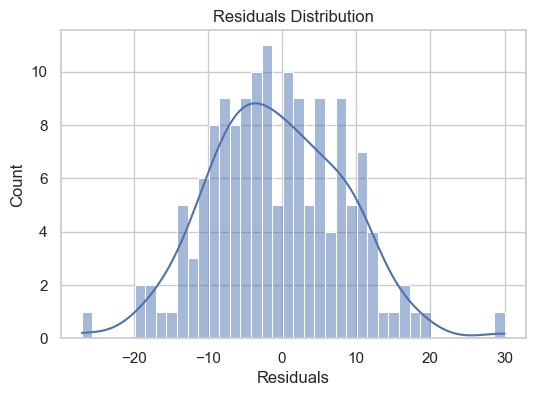

In [13]:
# Residuals histogram
residuals = y_test - predictions

plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=40, kde=True)
plt.xlabel('Residuals')
plt.title('Residuals Distribution')
plt.show()

The residuals are approximately normally distributed and centered around 0 — this confirms the linear regression assumptions are well satisfied.

## 11. Model Evaluation

In [14]:
mae  = metrics.mean_absolute_error(y_test, predictions)
mse  = metrics.mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2   = metrics.r2_score(y_test, predictions)

print(f'MAE  (Mean Absolute Error):       {mae:.4f}')
print(f'MSE  (Mean Squared Error):        {mse:.4f}')
print(f'RMSE (Root Mean Squared Error):   {rmse:.4f}')
print(f'R²   (R-squared):                 {r2:.4f}')

MAE  (Mean Absolute Error):       7.2281
MSE  (Mean Squared Error):        79.8131
RMSE (Root Mean Squared Error):   8.9338
R²   (R-squared):                 0.9890


**Evaluation Summary:**

| Metric | Value |
|--------|-------|
| MAE    | ~7.23 |
| MSE    | ~79.81 |
| RMSE   | ~8.93 |
| R²     | ~0.989 |

- **MAE of ~7.23** means the model is off by about \$7.23 on average — very low.
- **RMSE of ~8.93** is also very small relative to the target range (\$256 – \$765).
- **R² of 0.989** means the model explains **98.9%** of the variance in yearly spending — an excellent fit.

**Conclusion:** The Linear Regression model performs very well on this dataset. `Length of Membership` and `Time on App` are the most important predictors of how much a customer spends yearly.